# Modélisation stochastique : cinq études de cas en Python

Compte-rendu de synthèse - UE Modélisation, L2 Mathématiques-Économie
Licence Double-Diplôme Mathématiques et Économie, Université Paris-Saclay


## Introduction

Ce notebook regroupe les cinq travaux pratiques que j'ai fait dans le cadre de l'UE Modélisation en L2, dans ma licence double-diplôme Mathématiques et Économie à l'Université Paris-Saclay. Pour chaque thème on part du modèle mathématique, on le simule en Python, et on compare les résultats obtenus à ce que prédit la théorie

| # | Notebook | Thème |
|---|---|---|
| 1 | pileface.ipynb | Pile ou face : loi des grands nombres, Moivre-Laplace, planche de Galton |
| 2 | marche.ipynb | Marches aléatoires, ruine du joueur |
| 3 | coupons.ipynb | Collectionneur de coupons, loi de Gumbel |
| 4 | genetique.ipynb | Génétique des populations, modèles de Moran et Wright-Fisher |
| 5 | branchement.ipynb | Processus de branchement, Galton-Watson |


---
## 1. Pile ou face — probabilités et loi des grands nombres

Le jeu de pile ou face est l'expérience la plus simple pour observer les grands résultats de la théorie des probabilités. en répétant n fois une épreuve de Bernoulli de paramètre p on obtient une binomiale et son comportement quand n grandit illustre la loi des grands nombres, le théorème de Moivre-Laplace et l'approximation de Poisson. La planche de Galton permet en plus de voir tout ça de façon mécanique.


### 1.1 Bernoulli et loi des grands nombres

On simule n épreuves de Bernoulli indépendantes de paramètre p et on regarde la fréquence des succès. La loi des grands nombres dit que cette fréquence converge vers p quand n devient grand, c'est exactement ça qu'on voit sur le graphique de droite.


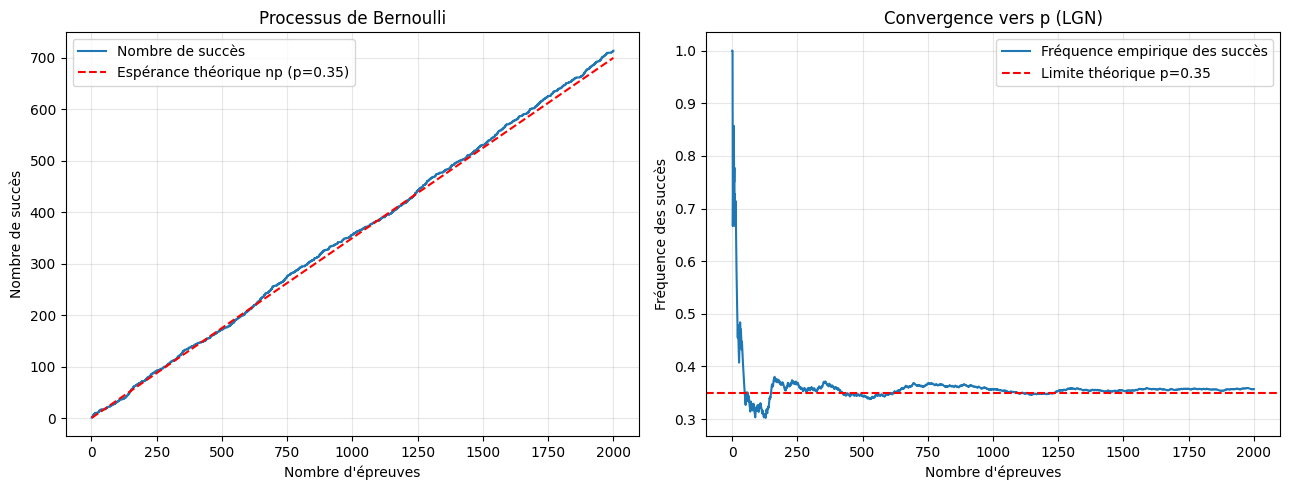

In [64]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(21)

p = 0.35
n = 2000

trials = np.random.rand(n) < p
cumulative_successes = np.cumsum(trials)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].step(range(1, n + 1), cumulative_successes, where='post', label='Nombre de succès')
ax[0].plot(range(1, n + 1), np.arange(1, n + 1) * p, linestyle='--', color='red',
           label=f'Espérance théorique np (p={p})')
ax[0].set_xlabel("Nombre d'épreuves")
ax[0].set_ylabel('Nombre de succès')
ax[0].set_title('Processus de Bernoulli')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(range(1, n + 1), cumulative_successes / np.arange(1, n + 1),
           label='Fréquence empirique des succès')
ax[1].axhline(y=p, color='red', linestyle='--', label=f'Limite théorique p={p}')
ax[1].set_xlabel("Nombre d'épreuves")
ax[1].set_ylabel('Fréquence des succès')
ax[1].set_title('Convergence vers p (LGN)')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 1.2 Approximation normale (Moivre-Laplace)

Quand n est grand, la binomiale ressemble de plus en plus à une loi normale $\mathcal{N}(np, np(1-p))$. On le voit bien ici avec n=60 : l'histogramme colle presque parfaitement à la courbe rouge.


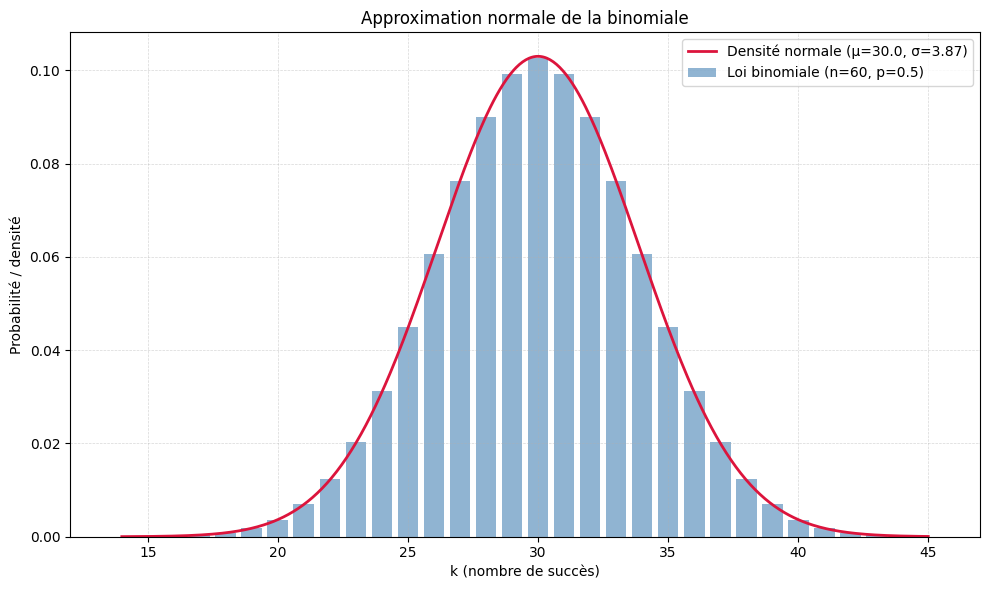

In [65]:
from scipy.stats import binom, norm

n, p = 60, 0.5
q = 1 - p
mean = n * p
stddev = np.sqrt(n * p * q)

low = max(0, int(mean - 4 * stddev))
high = min(n, int(mean + 4 * stddev))
x = np.arange(low, high + 1)
binom_probs = binom.pmf(x, n, p)

x_continuous = np.linspace(low, high, 500)
normal_density = norm.pdf(x_continuous, mean, stddev)

plt.figure(figsize=(10, 6))
plt.bar(x, binom_probs, width=0.8, color='steelblue', alpha=0.6,
        label=f'Loi binomiale (n={n}, p={p})')
plt.plot(x_continuous, normal_density, color='crimson', lw=2,
         label=f'Densité normale (µ={mean:.1f}, σ={stddev:.2f})')
plt.xlabel('k (nombre de succès)')
plt.ylabel('Probabilité / densité')
plt.title('Approximation normale de la binomiale')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### 1.3 La planche de Galton

La planche de Galton fait tomber des jetons à travers n niveaux de bifurcations, et chaque bifurcation envoie le jeton à droite avec probabilité p. La position finale suit une loi binomiale, donc la planche illustre physiquement le théorème de Moivre-Laplace.


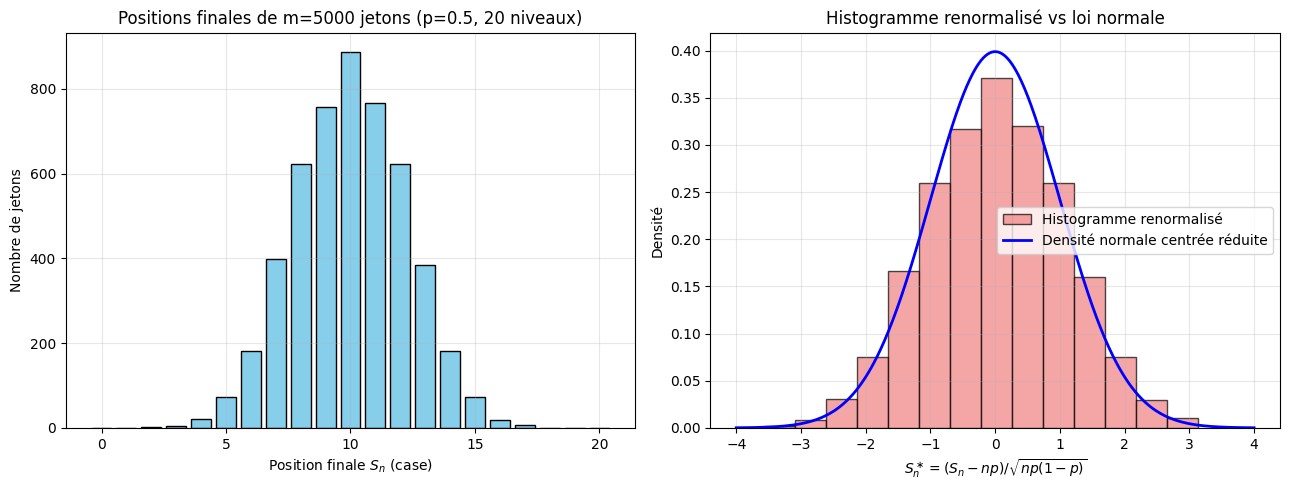

In [66]:
np.random.seed(0)

def galton_board(p, n, m):
    final_positions = np.zeros(m, dtype=int)
    for i in range(m):
        steps = np.random.choice([0, 1], size=n, p=[1 - p, p])
        final_positions[i] = np.sum(steps)

    mean = n * p
    std_dev = np.sqrt(n * p * (1 - p))
    Z = (final_positions - mean) / std_dev

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].hist(final_positions, bins=np.arange(n + 2) - 0.5, rwidth=0.8,
                 color='skyblue', edgecolor='black')
    axes[0].set_title(f"Positions finales de m={m} jetons (p={p}, {n} niveaux)")
    axes[0].set_xlabel("Position finale $S_n$ (case)")
    axes[0].set_ylabel("Nombre de jetons")
    axes[0].grid(alpha=0.3)

    xs = np.linspace(-4, 4, 500)
    axes[1].hist(Z, bins=int(np.ceil(np.log2(m) + 1)), density=True, color='lightcoral',
                 alpha=0.7, edgecolor='black', label="Histogramme renormalisé")
    axes[1].plot(xs, norm.pdf(xs), 'b-', lw=2, label="Densité normale centrée réduite")
    axes[1].set_title("Histogramme renormalisé vs loi normale")
    axes[1].set_xlabel(r"$S_n^\ast = (S_n - np)/\sqrt{np(1-p)}$")
    axes[1].set_ylabel("Densité")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

p, n, m = 0.5, 20, 5000
galton_board(p, n, m)


### 1.4 Approximation de Poisson

Quand n est grand et p petit, avec np = λ fixé, la binomiale se rapproche d'une loi de Poisson. C'est la loi des évènements rares, utile en assurance par exemple pour compter un nombre de sinistres. Ici n=300 et p=0.02 donc λ=6, et l'accord entre les deux lois est déjà très bon.


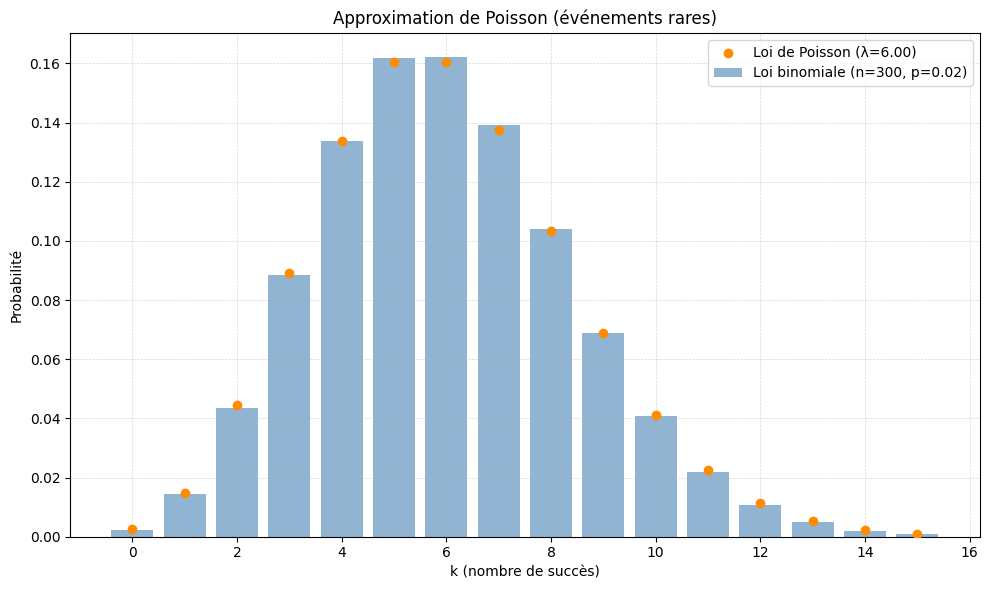

In [67]:
from scipy.stats import poisson

n, p = 300, 0.02
lambda_param = n * p

low = max(0, int(lambda_param - 4 * np.sqrt(lambda_param)))
high = min(n, int(lambda_param + 4 * np.sqrt(lambda_param)))
x = np.arange(low, high + 1)

binom_probs = binom.pmf(x, n, p)
poisson_probs = poisson.pmf(x, lambda_param)

plt.figure(figsize=(10, 6))
plt.bar(x, binom_probs, width=0.8, color='steelblue', alpha=0.6,
        label=f'Loi binomiale (n={n}, p={p})')
plt.scatter(x, poisson_probs, color='darkorange', zorder=3,
            label=f'Loi de Poisson (λ={lambda_param:.2f})')
plt.xlabel('k (nombre de succès)')
plt.ylabel('Probabilité')
plt.title("Approximation de Poisson (événements rares)")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


---
## 2. Marches aléatoires

La marche aléatoire est la brique de base de plein de processus stochastiques : elle sert à modéliser le mouvement brownien, les prix d'actifs en finance, ou encore la dérive génétique qu'on retrouve en partie 4. On l'étudie ici sur Z, avec le problème de la ruine du joueur, puis dans le plan et dans l'espace.


### 2.1 Marche simple sur Z

À chaque instant la particule fait un pas +1 avec probabilité p et -1 sinon. Pour p=1/2, cas tracé ici, la position $S_n$ est une martingale et son écart-type grandit en $\sqrt{n}$.


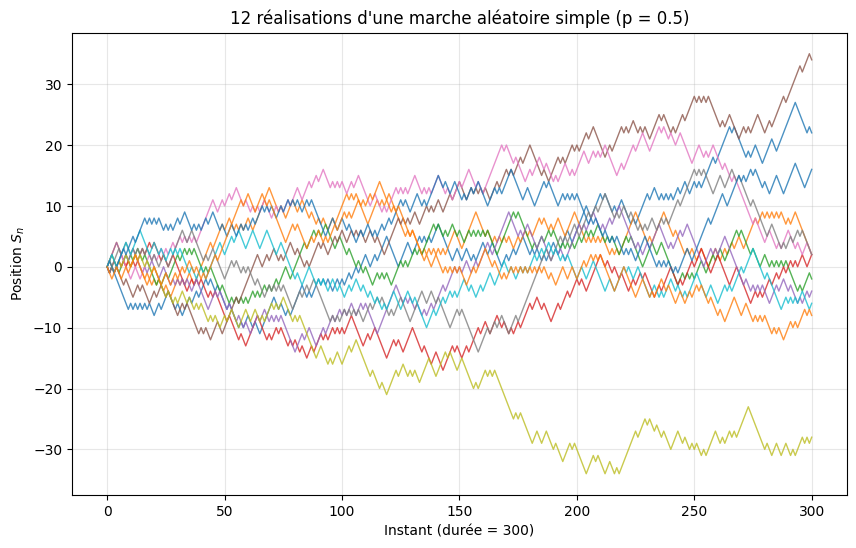

In [68]:
np.random.seed(1)

def simulate_random_walks(m, n, p):
    plt.figure(figsize=(10, 6))
    for i in range(m):
        steps = np.random.choice([-1, 1], size=n, p=[1 - p, p])
        walk = np.cumsum(steps)
        walk = np.insert(walk, 0, 0)
        plt.plot(range(n + 1), walk, alpha=0.8, linewidth=1)
    plt.title(f"{m} réalisations d'une marche aléatoire simple (p = {p})")
    plt.xlabel(f"Instant (durée = {n})")
    plt.ylabel("Position $S_n$")
    plt.grid(True, alpha=0.3)
    plt.show()

m, n, p = 12, 300, 0.5
simulate_random_walks(m, n, p)


### 2.2 La ruine du joueur

un joueur part avec un capital k, gagne un tour avec probabilité p, et s'arrête quand il atteint 0 (ruine) ou b (objectif). Quand p≠1/2, la probabilité de ruine a une formule fermée obtenue avec $\left(\frac{1-p}{p}\right)^{S_n}$ :

$$\mathbb{P}(\text{ruine} \mid X_0=k) = \frac{r^k - r^b}{r^a - r^b}, \qquad r = \frac{1-p}{p}$$

On vérifie cette formule numériquement juste en dessous, avec le meme raisonnement pour comparer simulation et théorie.


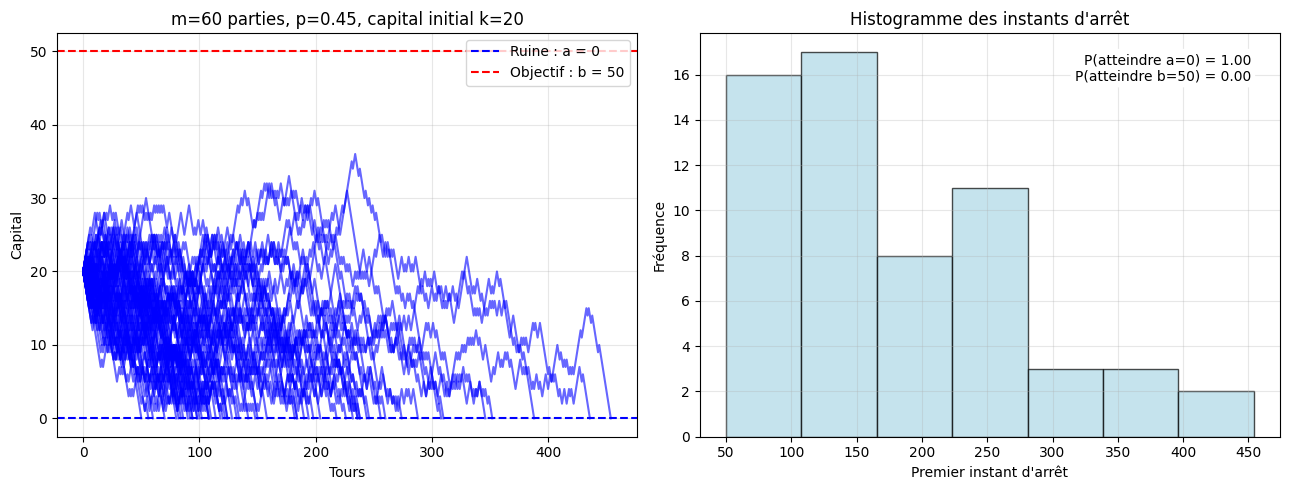

proportion simulée : 1.000
proba théorique : 0.998


In [69]:
np.random.seed(32)

def simulate_ruin(p, a, k, b, m):
    hitting_times = []
    reaches_a = 0
    marches = []
    colors = []

    for _ in range(m):
        position = k
        trajectory = [position]
        time = 0
        while position != a and position != b:
            step = 1 if np.random.rand() < p else -1
            position += step
            trajectory.append(position)
            time += 1
        hitting_times.append(time)
        marches.append(trajectory)
        if position == a:
            reaches_a += 1
            colors.append('blue')
        else:
            colors.append('red')

    proportion_a = reaches_a / m
    proportion_b = 1 - proportion_a

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for march, color in zip(marches, colors):
        axes[0].plot(range(len(march)), march, color=color, alpha=0.6)
    axes[0].axhline(a, color='blue', linestyle='--', label=f"Ruine : a = {a}")
    axes[0].axhline(b, color='red', linestyle='--', label=f"Objectif : b = {b}")
    axes[0].set_title(f"m={m} parties, p={p}, capital initial k={k}")
    axes[0].set_xlabel("Tours")
    axes[0].set_ylabel("Capital")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].hist(hitting_times, bins=int(np.sqrt(m)), color='lightblue',
                 edgecolor='black', alpha=0.7)
    axes[1].set_title("Histogramme des instants d'arrêt")
    axes[1].set_xlabel("Premier instant d'arrêt")
    axes[1].set_ylabel("Fréquence")
    axes[1].text(
        0.95, 0.95,
        f"P(atteindre a={a}) = {proportion_a:.2f}\nP(atteindre b={b}) = {proportion_b:.2f}",
        ha='right', va='top', transform=axes[1].transAxes,
        bbox=dict(boxstyle="round,pad=0.3", edgecolor='none', facecolor='white')
    )
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return proportion_a, proportion_b

p, a, b, k, m = 0.45, 0, 50, 20, 60
prop_a, prop_b = simulate_ruin(p, a, k, b, m)

r = (1 - p) / p
theo_prop_a = (r**k - r**b) / (r**a - r**b)
print(f"proportion simulée : {prop_a:.3f}")
print(f"proba théorique : {theo_prop_a:.3f}")


### 2.3 Marche aléatoire dans le plan

Même construction mais sur $\mathbb{Z}^2$, avec 4 directions équiprobables à chaque étape. Le dégradé de bleu permet de voir l'évolution dans le temps le long de la trajectoire.


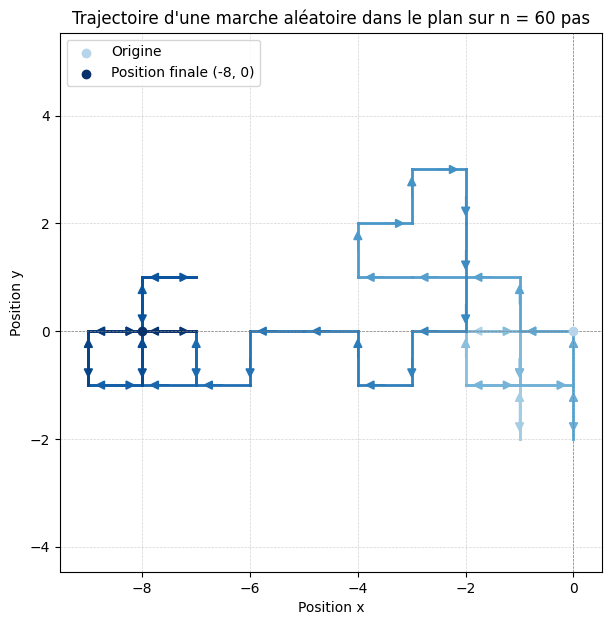

In [70]:
np.random.seed(4)

n = 60
directions = np.random.choice(['haut', 'bas', 'gauche', 'droite'], size=n)
x, y = [0], [0]
for direction in directions:
    if direction == 'haut':
        x.append(x[-1]); y.append(y[-1] + 1)
    elif direction == 'bas':
        x.append(x[-1]); y.append(y[-1] - 1)
    elif direction == 'gauche':
        x.append(x[-1] - 1); y.append(y[-1])
    elif direction == 'droite':
        x.append(x[-1] + 1); y.append(y[-1])

colors = plt.cm.Blues(np.linspace(0.3, 1, len(x)))

plt.figure(figsize=(7, 7))
for i in range(len(x) - 1):
    plt.plot(x[i:i+2], y[i:i+2], color=colors[i], linewidth=2)
    dx, dy = x[i+1]-x[i], y[i+1]-y[i]
    plt.arrow(x[i] + dx/2, y[i] + dy/2, dx*0.2, dy*0.2,
              head_width=0.15, head_length=0.15, fc=colors[i], ec=colors[i])
plt.scatter(0, 0, color=colors[0], label='Origine', zorder=5)
plt.scatter(x[-1], y[-1], color=colors[-1], label=f'Position finale ({x[-1]}, {y[-1]})', zorder=5)
plt.title(f"Trajectoire d'une marche aléatoire dans le plan sur n = {n} pas")
plt.xlabel("Position x")
plt.ylabel("Position y")
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.legend()
plt.axis('equal')
plt.show()


### 2.4 Marche aléatoire dans l'espace

Et enfin en 3D avec 6 directions possibles, plusieurs trajectoires superposées pour voir comment le nuage de marches se disperse dans l'espace.


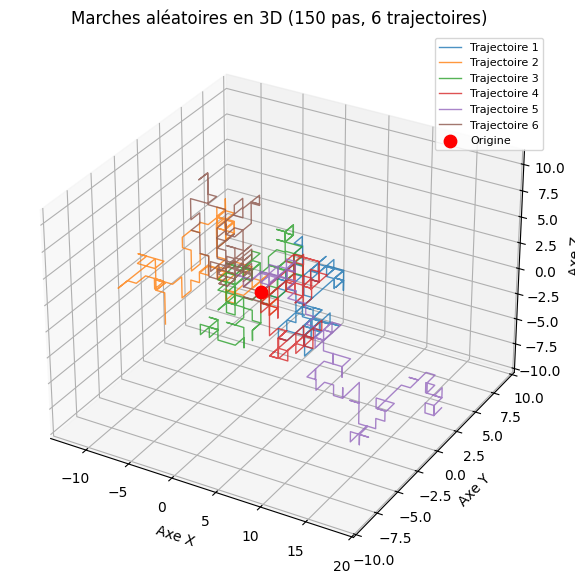

In [71]:
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(4)

n, m = 150, 6
directions = np.array([
    [1, 0, 0], [-1, 0, 0],
    [0, 1, 0], [0, -1, 0],
    [0, 0, 1], [0, 0, -1],
])

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for trajectory in range(m):
    positions = np.zeros((n + 1, 3))
    for i in range(1, n + 1):
        direction = directions[np.random.choice(len(directions))]
        positions[i] = positions[i - 1] + direction
    ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], lw=1, alpha=0.8,
            label=f'Trajectoire {trajectory + 1}')

ax.scatter(0, 0, 0, color='red', s=80, label='Origine')
ax.set_xlabel('Axe X')
ax.set_ylabel('Axe Y')
ax.set_zlabel('Axe Z')
ax.set_title(f"Marches aléatoires en 3D ({n} pas, {m} trajectoires)")
ax.legend(fontsize=8)
plt.show()


---
## 3. Le collectionneur de coupons

on tire avec remise des coupons parmi r types différents, et on se demande combien de tirages il faut en moyenne pour tous les avoir. L'espérance du temps de recouvrement $T(r)$ vaut environ $r\ln r$, et les fluctuations autour de cette moyenne suivent, une fois renormalisées, une loi de Gumbel.


### 3.1 Une collecte

On simule une collecte complète pour r=50 coupons, et on trace le nombre de coupons distincts obtenus en fonction du nombre de tirages. Le temps de recouvrement obtenu est comparé à $r\ln r$.


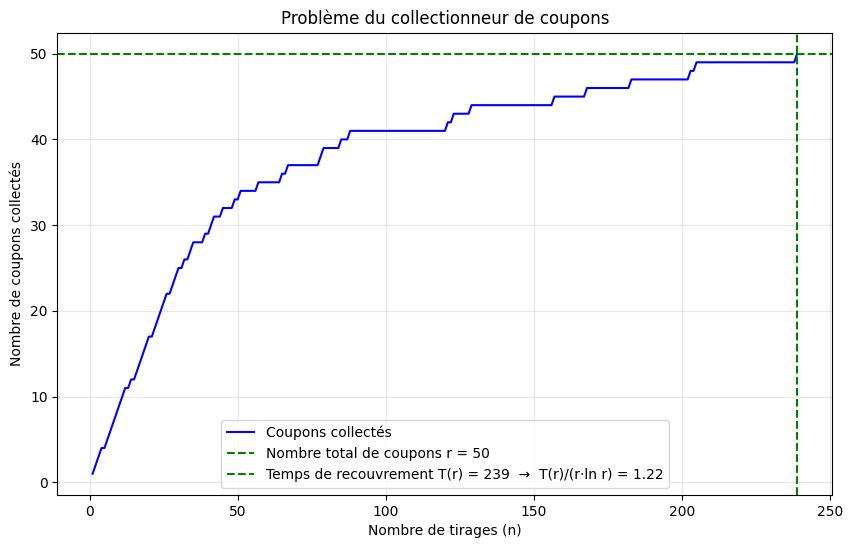

In [72]:
import math
import random

random.seed(10)

r = 50

coupons = set(range(1, r + 1))
collected_coupons = set()
n = 0
collected_counts = []

while len(collected_coupons) < r:
    n += 1
    new_coupon = random.randint(1, r)
    if new_coupon not in collected_coupons:
        collected_coupons.add(new_coupon)
    collected_counts.append(len(collected_coupons))

r_ln_r = r * math.log(r)
ratio = n / r_ln_r

plt.figure(figsize=(10, 6))
plt.plot(range(1, n + 1), collected_counts, label="Coupons collectés", color="blue")
plt.xlabel("Nombre de tirages (n)")
plt.ylabel("Nombre de coupons collectés")
plt.title("Problème du collectionneur de coupons")
plt.axhline(y=r, color='green', linestyle='--', label=f"Nombre total de coupons r = {r}")
plt.axvline(x=n, color='green', linestyle='--',
            label=f"Temps de recouvrement T(r) = {n}  →  T(r)/(r·ln r) = {ratio:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 3.2 Fluctuations et loi de Gumbel

En répétant l'expérience m fois, on construit la statistique renormalisée $\ln(r)\left(\frac{T(r)}{r\ln r} - 1\right)$ et on compare sa fonction de répartition empirique à celle de la loi de Gumbel. L'accord est plutôt bon.


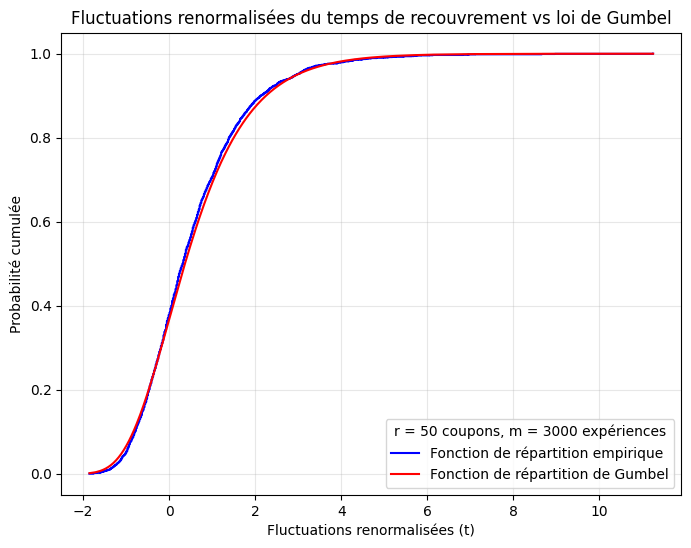

In [73]:
random.seed(67)

def simulate_coupon_collector(r):
    collected_coupons = set()
    n = 0
    while len(collected_coupons) < r:
        n += 1
        new_coupon = random.randint(1, r)
        if new_coupon not in collected_coupons:
            collected_coupons.add(new_coupon)
    return n

r = 50
m = 3000

results = [simulate_coupon_collector(r) for _ in range(m)]
adjustment_vector = [math.log(r) * ((n_ / (r * math.log(r))) - 1) for n_ in results]

sorted_adjustments = np.sort(adjustment_vector)
cdf = np.arange(1, len(sorted_adjustments) + 1) / len(sorted_adjustments)
gumbel_cdf = np.exp(-np.exp(-sorted_adjustments))

plt.figure(figsize=(8, 6))
plt.step(sorted_adjustments, cdf, where="post", color="b", label="Fonction de répartition empirique")
plt.plot(sorted_adjustments, gumbel_cdf, color="r", label="Fonction de répartition de Gumbel")
plt.title("Fluctuations renormalisées du temps de recouvrement vs loi de Gumbel")
plt.xlabel("Fluctuations renormalisées (t)")
plt.ylabel("Probabilité cumulée")
plt.legend(title=f"r = {r} coupons, m = {m} expériences")
plt.grid(alpha=0.3)
plt.show()


### 3.3 Densité de Gumbel

Pour référence, la densité de la loi de Gumbel standard, avec sa queue de droite plus épaisse qu'une gaussienne.


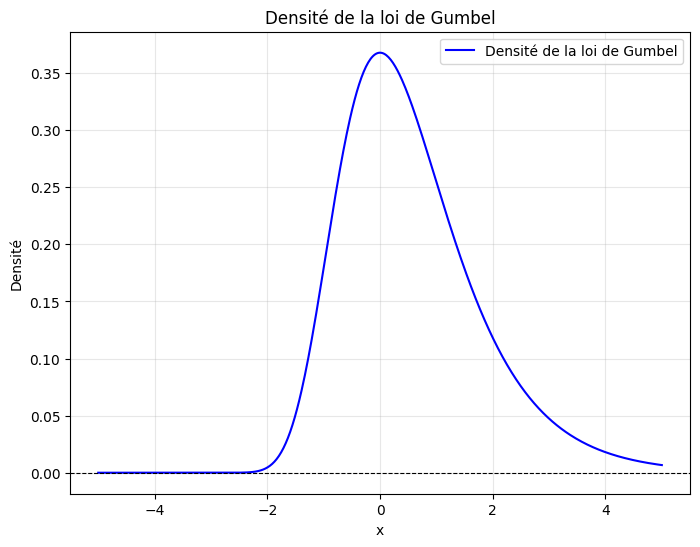

In [74]:
def gumbel_density(x):
    return np.exp(-x - np.exp(-x))

x = np.linspace(-5, 5, 500)
y = gumbel_density(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y, label="Densité de la loi de Gumbel", color="blue")
plt.title("Densité de la loi de Gumbel")
plt.xlabel("x")
plt.ylabel("Densité")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


---
## 4. Génétique des populations

Sans sélection ni mutation, la fréquence d'un allèle dans une population de taille N évolue seulement par hasard : c'est la dérive génétique. Deux modèles classiques permettent de la formaliser : le modèle de Moran, où à chaque étape un individu se reproduit et un autre meurt, et le modèle de Wright-Fisher, où chaque generation est tirée par échantillonnage binomial. Dans les deux cas $X_n$ est une martingale bornée, donc le processus finit par se fixer, et la probabilité de fixation de A vaut exactement sa fréquence initiale k/N.


### 4.1 Modèle de Moran

Population de taille N=100, fréquence initiale k=50. On trace les trajectoires de $X_n$ (rouge = extinction, bleu = fixation) et l'histogramme des temps de fixation.


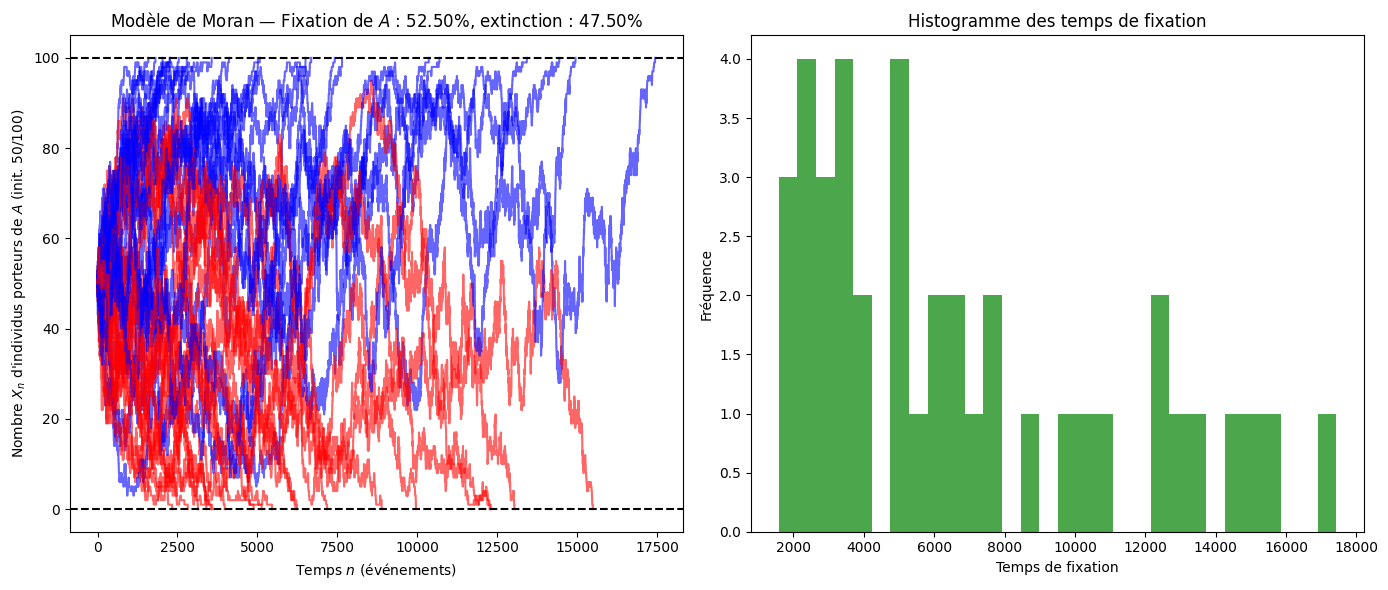

fixation de A observée : 52.50%  (théorie k/N = 50.00%)


In [75]:
np.random.seed(20)

def moran_simulation(N, k, m):
    trajectories = []
    fixation_times = []
    fixation_types = []

    for _ in range(m):
        X = [k]
        while True:
            current_X = X[-1]
            if current_X == 0 or current_X == N:
                fixation_times.append(len(X) - 1)
                fixation_types.append(0 if current_X == 0 else 1)
                break
            chosen = np.random.choice(N, 2, replace=True) + 1
            allele1 = 1 if chosen[0] <= current_X else 0
            allele2 = 1 if chosen[1] <= current_X else 0
            if allele1 == 1 and allele2 == 0:
                new_X = current_X + 1
            elif allele1 == 0 and allele2 == 1:
                new_X = current_X - 1
            else:
                new_X = current_X
            X.append(new_X)
        trajectories.append(X)

    prop_extinct = fixation_types.count(0) / m
    prop_fix = fixation_types.count(1) / m

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    for i, traj in enumerate(trajectories):
        color = 'red' if fixation_types[i] == 0 else 'blue'
        plt.plot(traj, color=color, alpha=0.6)
    plt.title(f'Modèle de Moran — Fixation de $A$ : {prop_fix:.2%}, extinction : {prop_extinct:.2%}')
    plt.xlabel('Temps $n$ (événements)')
    plt.ylabel(f"Nombre $X_n$ d'individus porteurs de $A$ (init. {k}/{N})")
    plt.axhline(y=0, color='black', linestyle='--')
    plt.axhline(y=N, color='black', linestyle='--')

    plt.subplot(1, 2, 2)
    plt.hist(fixation_times, bins=30, color='green', alpha=0.7)
    plt.title('Histogramme des temps de fixation')
    plt.xlabel('Temps de fixation')
    plt.ylabel('Fréquence')

    plt.tight_layout()
    plt.show()
    return prop_fix

N, k, m = 100, 50, 40
prop_fix = moran_simulation(N, k, m)
print(f"fixation de A observée : {prop_fix:.2%}  (théorie k/N = {50/100:.2%})")


### 4.2 Modèle de Wright-Fisher

Même expérience mais avec des générations non chevauchantes. Les trajectoires sont plus heurtées, et le temps de fixation en générations est beaucoup plus court qu'en nombre d'événements du modèle de Moran, ce qui est cohérent puisqu'une génération correspond à peu près à N événements de Moran.


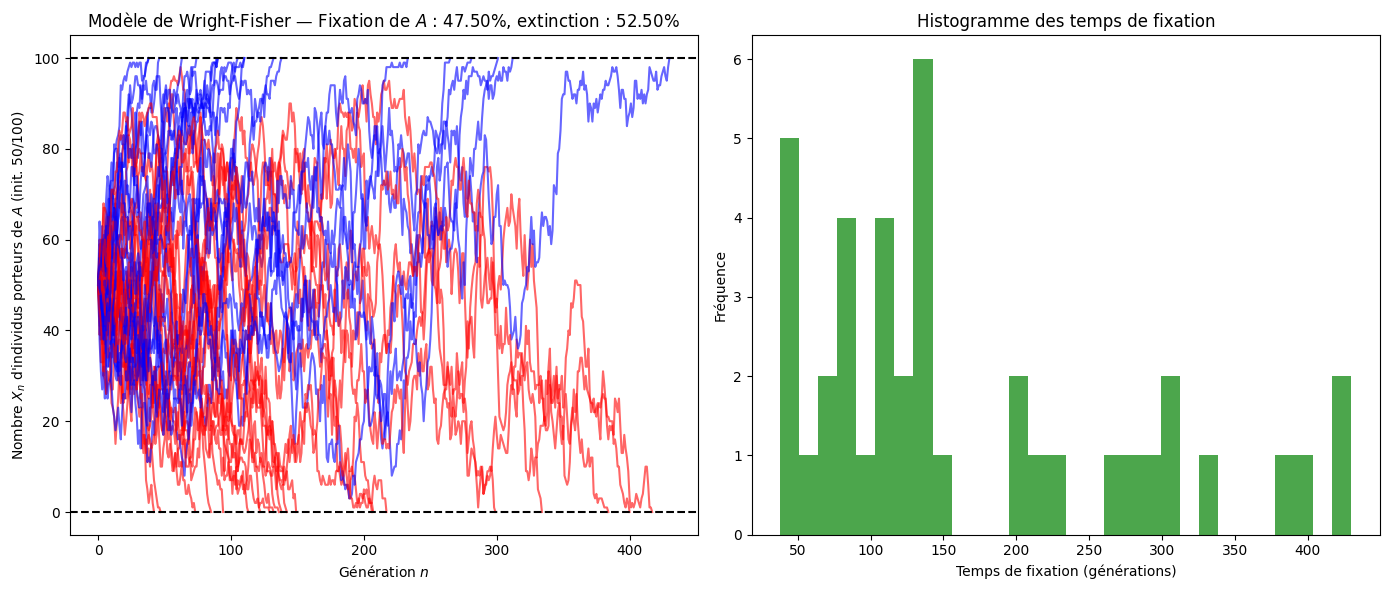

fixation de A observée : 47.50%  (théorie k/N = 50.00%)
temps moyen de fixation : 170.3 générations


In [76]:
np.random.seed(21)

def wright_fisher_simulation(N, k, m):
    trajectories = []
    fixation_times = []
    fixation_types = []

    for _ in range(m):
        X = [k]
        while True:
            current_X = X[-1]
            if current_X == 0 or current_X == N:
                fixation_times.append(len(X) - 1)
                fixation_types.append(0 if current_X == 0 else 1)
                break
            new_X = np.random.binomial(N, current_X / N)
            X.append(new_X)
        trajectories.append(X)

    prop_extinct = fixation_types.count(0) / m
    prop_fix = fixation_types.count(1) / m

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    for i, traj in enumerate(trajectories):
        color = 'red' if fixation_types[i] == 0 else 'blue'
        plt.plot(traj, color=color, alpha=0.6)
    plt.title(f'Modèle de Wright-Fisher — Fixation de $A$ : {prop_fix:.2%}, extinction : {prop_extinct:.2%}')
    plt.xlabel('Génération $n$')
    plt.ylabel(f"Nombre $X_n$ d'individus porteurs de $A$ (init. {k}/{N})")
    plt.axhline(y=0, color='black', linestyle='--')
    plt.axhline(y=N, color='black', linestyle='--')

    plt.subplot(1, 2, 2)
    plt.hist(fixation_times, bins=30, color='green', alpha=0.7)
    plt.title('Histogramme des temps de fixation')
    plt.xlabel('Temps de fixation (générations)')
    plt.ylabel('Fréquence')

    plt.tight_layout()
    plt.show()
    return prop_fix, np.mean(fixation_times)

N, k, m = 100, 50, 40
prop_fix, mean_time = wright_fisher_simulation(N, k, m)
print(f"fixation de A observée : {prop_fix:.2%}  (théorie k/N = {50/100:.2%})")
print(f"temps moyen de fixation : {mean_time:.1f} générations")


---
## 5. Processus de branchement (Galton-Watson)

Le processus de Galton-Watson modélise une population où chaque individu se reproduit indépendamment selon la même loi $(p_k)$, avec $Z_0=1$. Le comportement de $Z_n$ dépend entièrement de l'espérance m de la loi de reproduction :

- m<1 : sous-critique, extinction presque sûre
- m=1 : critique, extinction presque sûre aussi mais plus lente
- m>1 : sur-critique, extinction possible mais pas certaine

La probabilité d'extinction q est la plus petite racine dans [0,1] de $G(x)=x$, où G est la fonction génératrice de la loi de reproduction.


### 5.1 Les trois régimes

On simule 8 processus indépendants pour chacun des 3 régimes, avec des lois de reproduction sur {0,1,2}. On utilise une échelle log dans le cas sur-critique parce que $Z_n$ y grandit vite, en $m^n$.


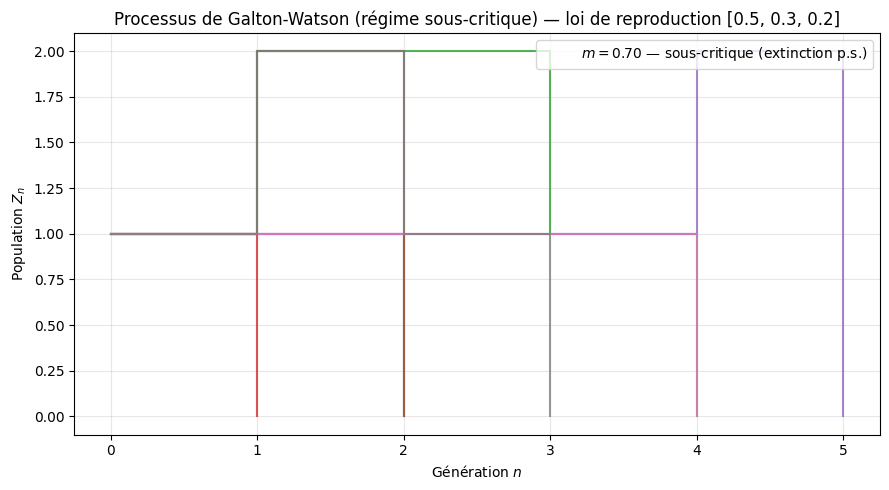

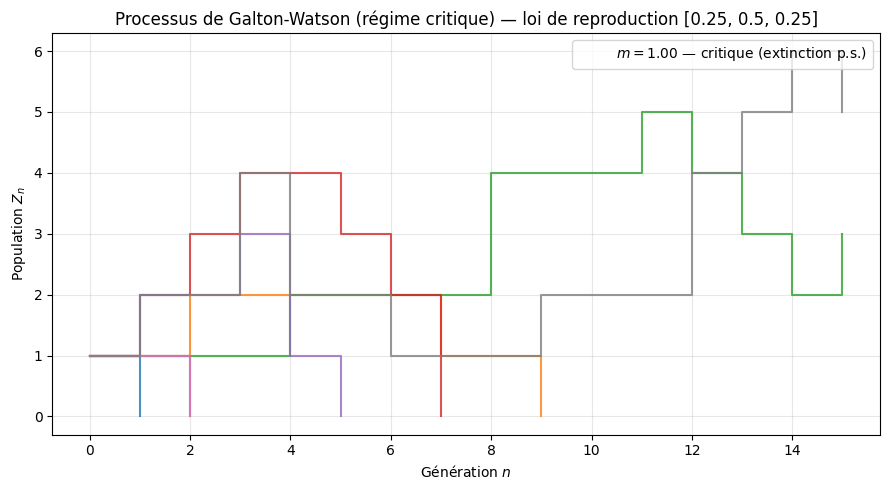

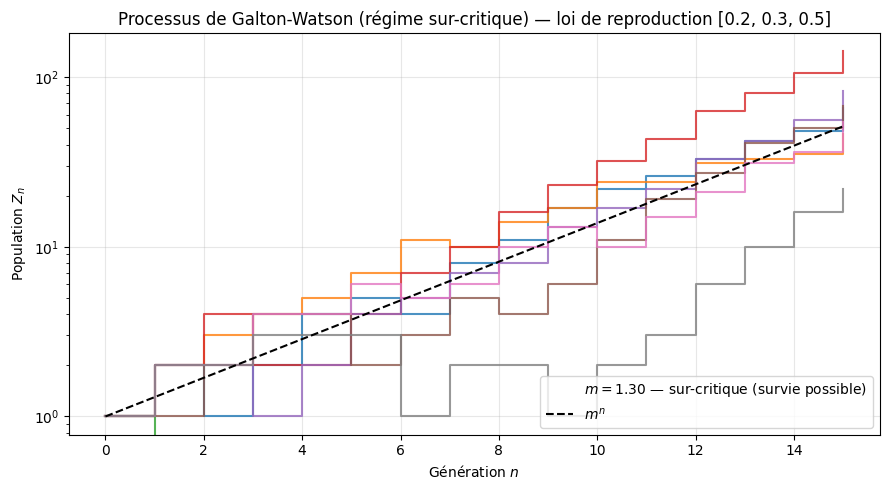

In [77]:
np.random.seed(30)

def simulate_galton_watson(r, coefficients, max_generations):
    results = []
    for _ in range(r):
        population = [1]
        for n in range(1, max_generations + 1):
            next_population = sum(np.random.choice(len(coefficients), size=population[-1], p=coefficients))
            population.append(next_population)
            if next_population == 0:
                break
        results.append(population)
    return results

def plot_results(results, coefficients, max_generations, title_suffix=""):
    plt.figure(figsize=(9, 5))
    expectation = sum(k * p for k, p in enumerate(coefficients))

    for i, population in enumerate(results):
        n_values = np.arange(len(population))
        Z_values = population
        plt.step(n_values, Z_values, where='post', alpha=0.8)

    if expectation < 1:
        regime = "sous-critique (extinction p.s.)"
    elif expectation == 1:
        regime = "critique (extinction p.s.)"
    else:
        regime = "sur-critique (survie possible)"

    plt.plot([], [], ' ', label=f'$m = {expectation:.2f}$ — {regime}')

    if expectation > 1:
        generations = np.arange(0, max_generations + 1)
        m_n = expectation ** generations
        plt.plot(generations, m_n, 'k--', label=f'$m^n$')

    plt.xlabel('Génération $n$')
    plt.ylabel('Population $Z_n$')
    plt.title(f'Processus de Galton-Watson {title_suffix} — loi de reproduction {coefficients}')
    plt.legend(loc='upper right' if expectation <= 1 else 'lower right')
    plt.grid(True, alpha=0.3)
    if expectation > 1:
        plt.yscale('log')
    plt.tight_layout()
    plt.show()

r = 8
max_generations = 15

regimes = [
    ("(régime sous-critique)", [0.5, 0.3, 0.2]),
    ("(régime critique)",      [0.25, 0.5, 0.25]),
    ("(régime sur-critique)",  [0.2, 0.3, 0.5]),
]

for label, coeffs in regimes:
    results = simulate_galton_watson(r, coeffs, max_generations)
    plot_results(results, coeffs, max_generations, title_suffix=label)


### 5.2 Fonction génératrice — loi de Poisson

Pour une loi de Poisson $\mathcal{P}(\lambda)$, $G(x)=e^{\lambda(x-1)}$ et m=λ. Quand λ>1 la courbe recoupe la bissectrice en un point q dans (0,1), qui est la probabilité d'extinction. Quand λ≤1 le seul point fixe est x=1 et l'extinction est certaine.


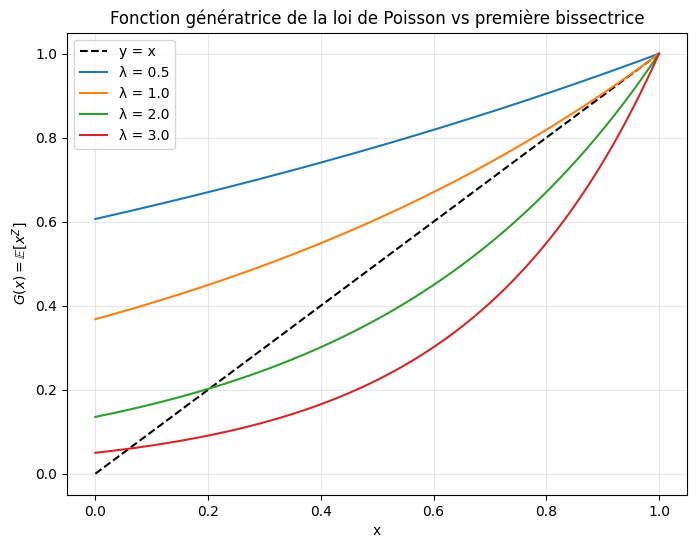

In [78]:
lambda_values = [0.5, 1.0, 2.0, 3.0]
x = np.linspace(0, 1, 500)

plt.figure(figsize=(8, 6))
plt.plot(x, x, label='y = x', color='black', linestyle='--')
for lam in lambda_values:
    y = np.exp(lam * (x - 1))
    plt.plot(x, y, label=f'λ = {lam}')
plt.xlabel('x')
plt.ylabel('$G(x) = \\mathbb{E}[x^Z]$')
plt.title('Fonction génératrice de la loi de Poisson vs première bissectrice')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 5.3 Fonction génératrice — loi géométrique

Même logique pour une loi géométrique de paramètre p, avec $G(x)=\frac{p}{1-(1-p)x}$. On retrouve la même distinction sous/sur-critique selon la position de m=(1-p)/p par rapport à 1.


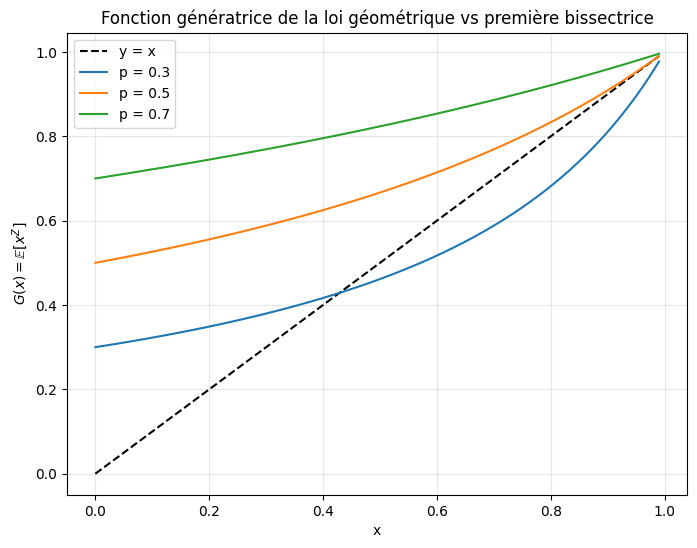

In [79]:
p_values = [0.3, 0.5, 0.7]
x = np.linspace(0, 0.99, 500)

plt.figure(figsize=(8, 6))
plt.plot(x, x, label='y = x', color='black', linestyle='--')
for p in p_values:
    y = p / (1 - (1 - p) * x)
    plt.plot(x, y, label=f'p = {p}')
plt.xlabel('x')
plt.ylabel('$G(x) = \\mathbb{E}[x^Z]$')
plt.title('Fonction génératrice de la loi géométrique vs première bissectrice')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## Conclusion

Ces cinq modèles n'ont l'air d'avoir rien en commun au premier abord, mais on retrouve à chaque fois la même démarche : poser un modèle stochastique simple, le simuler, puis vérifier que les résultats collent à la théorie (loi des grands nombres, TCL, valeurs extrêmes, martingales, criticité...)

ces outils reviennent aussi beaucoup en économie : marches aléatoires en finance, processus de branchement en démographie et en épidémiologie, dérive génétique comme modèle de diffusion d'un comportement dans une population